In [10]:
import pandas as pd
import nibabel as nib
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path
from tqdm import tqdm
import torch
from multiprocessing import Pool, cpu_count
import matplotlib.patches as mpatches

In [11]:
CSV = '../data/processed_dataset/GLCM/2d_1_slice_texture_radiomics_dataset_clean.csv'
REPORT = "../mirp-radiomics-extraction/roi_sizes_report.csv"
MARGIN      = 40
TARGET_SIZE = 224
DATASET = pd.read_csv(CSV)

In [12]:
idx = [random.randint(a=0, b=len(DATASET)) for i in range(5)]
idx

[29149, 7031, 38682, 12145, 49765]

In [13]:
# idx = [39955, 48649, 19470, 46707, 42482]

## Test Crop based on p90

In [ ]:
def load_slice(row):
    ct_data   = nib.load(row["ct_image_path"]).get_fdata(dtype=np.float32)
    mask_data = nib.load(row["mask_path"]).get_fdata(dtype=np.float32)
    mask_data = (mask_data > 0).astype(np.float32)
    z         = int(row["z_middle_global"])

    mask_2d = mask_data[z]
    yx      = np.where(mask_2d > 0)
    if yx[0].size == 0:
        return None, None, None

    return ct_data, mask_data, z

def normalize_for_display(ct, window_center=40, window_width=400):
    lo = window_center - window_width / 2
    hi = window_center + window_width / 2
    return (np.clip(ct, lo, hi) - lo) / (hi - lo)

def overlay_mask(ct_disp, mask, alpha=0.2):
    rgb = np.stack([ct_disp] * 3, axis=-1).copy()
    rgb[mask > 0.5, 0] = np.clip(rgb[mask > 0.5, 0] + alpha, 0, 1)
    rgb[mask > 0.5, 1] = np.clip(rgb[mask > 0.5, 1] - alpha * 0.5, 0, 1)
    rgb[mask > 0.5, 2] = np.clip(rgb[mask > 0.5, 2] - alpha * 0.5, 0, 1)
    return rgb
def analyze_percentiles(report_csv):
    """
    Shows the ROI size distribution and candidate crop sizes
    for p90, p95, p99 and max. Run this first to pick your crop size.
    """
    report = pd.read_csv(report_csv)
    valid  = report[report["status"] == "ok"]["roi_max"].dropna()

    p90 = int(np.percentile(valid, 90))
    p95 = int(np.percentile(valid, 95))
    p99 = int(np.percentile(valid, 99))
    pmax = int(valid.max())

    print("── ROI Size Percentiles ────────────────────────────────────────")
    print(f"  p90  : {p90}px   → crop window = {p90  + MARGIN}px  "
          f"→ scale factor = {TARGET_SIZE / (p90  + MARGIN):.4f}  "
          f"| {(valid > p90).sum()} ROIs clipped ({100*(valid>p90).mean():.1f}%)")
    print(f"  p95  : {p95}px   → crop window = {p95  + MARGIN}px  "
          f"→ scale factor = {TARGET_SIZE / (p95  + MARGIN):.4f}  "
          f"| {(valid > p95).sum()} ROIs clipped ({100*(valid>p95).mean():.1f}%)")
    print(f"  p99  : {p99}px   → crop window = {p99  + MARGIN}px  "
          f"→ scale factor = {TARGET_SIZE / (p99  + MARGIN):.4f}  "
          f"| {(valid > p99).sum()} ROIs clipped ({100*(valid>p99).mean():.1f}%)")
    print(f"  max  : {pmax}px  → crop window = {pmax + MARGIN}px  "
          f"→ scale factor = {TARGET_SIZE / (pmax + MARGIN):.4f}  "
          f"| 0 ROIs clipped (0.0%)")
    print()

    return {"p90": p90, "p95": p95, "p99": p99, "max": pmax}

def shifted_crop_2d(ct_slice, mask_slice, crop_size):
    """
    Center crop on ROI, but shift the window if it goes out of boundaries. And no padding
    """

    yx = np.where(mask_slice > 0)

    # safety check
    if len(yx[0]) == 0:
        return None, None, {"error": "empty mask"}

    # ROI center (bounding box center)
    cy = int((yx[0].min() + yx[0].max()) / 2)
    cx = int((yx[1].min() + yx[1].max()) / 2)
    
    half = crop_size // 2

    # initial window
    y1 = cy - half
    y2 = cy + half
    x1 = cx - half
    x2 = cx + half

    img_h, img_w = ct_slice.shape
    if y1 < 0:
        y2 += -y1
        y1 = 0
    if y2 > img_h:
        y1 -= (y2 - img_h)
        y2 = img_h

    if x1 < 0:
        x2 += -x1
        x1 = 0
    if x2 > img_w:
        x1 -= (x2 - img_w)
        x2 = img_w

    # final safety (important for extreme cases)
    y1 = max(0, y1)
    x1 = max(0, x1)
    y2 = min(img_h, y1 + crop_size)
    x2 = min(img_w, x1 + crop_size)

    ct_crop   = ct_slice[y1:y2, x1:x2]
    mask_crop = mask_slice[y1:y2, x1:x2]

    # ROI size
    roi_h = int(yx[0].max() - yx[0].min())
    roi_w = int(yx[1].max() - yx[1].min())

    meta = {
        "cy": cy, "cx": cx,
        "roi_h": roi_h, "roi_w": roi_w,
        "roi_max": max(roi_h, roi_w),
        "clipped": roi_h > crop_size or roi_w > crop_size,
        "shifted": (
            cy - half < 0 or cy + half > img_h or
            cx - half < 0 or cx + half > img_w
        )
    }

    return ct_crop, mask_crop, meta


## SHIFT method

In [15]:
def compare_crop_sizes(csv_path, crop_sizes, n_samples=4):
    dataset = pd.read_csv(csv_path)
    n_crops = len(crop_sizes)

    fig, axes = plt.subplots(len(idx), n_crops, figsize=(4.5 * n_crops, 4.5 * len(idx)))
    if len(idx) == 1: axes = [axes]

    for i, pid in enumerate(idx):
        for j, cs in enumerate(crop_sizes):
            axes[i][j].set_title(f"crop: {cs}px | scale: {TARGET_SIZE/cs:.3f} | pid: {pid}",fontweight="bold")
        row = dataset.iloc[pid]
        ct_data, mask_data, z = load_slice(row)
        if ct_data is None:
            continue
        ct_slice   = ct_data[z]
        mask_slice = mask_data[z]

        for j, cs in enumerate(crop_sizes):
            ct_crop, mask_crop, meta = shifted_crop_2d(ct_slice, mask_slice, cs)
            ct_scaled   = cv2.resize(ct_crop,   (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_LANCZOS4)
            mask_scaled = cv2.resize(mask_crop, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_NEAREST)
            axes[i][j].imshow(overlay_mask(normalize_for_display(ct_scaled), mask_scaled))
            axes[i][j].axis("off")


    plt.suptitle(f"SHIFT method - Same samples - different crop sizes - all scaled to {TARGET_SIZE}×{TARGET_SIZE}", fontweight="bold", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

── ROI Size Percentiles ────────────────────────────────────────
  p90  : 114px   → crop window = 154px  → scale factor = 1.4545  | 5008 ROIs clipped (9.8%)
  p95  : 141px   → crop window = 181px  → scale factor = 1.2376  | 2514 ROIs clipped (4.9%)
  p99  : 220px   → crop window = 260px  → scale factor = 0.8615  | 502 ROIs clipped (1.0%)
  max  : 712px  → crop window = 752px  → scale factor = 0.2979  | 0 ROIs clipped (0.0%)



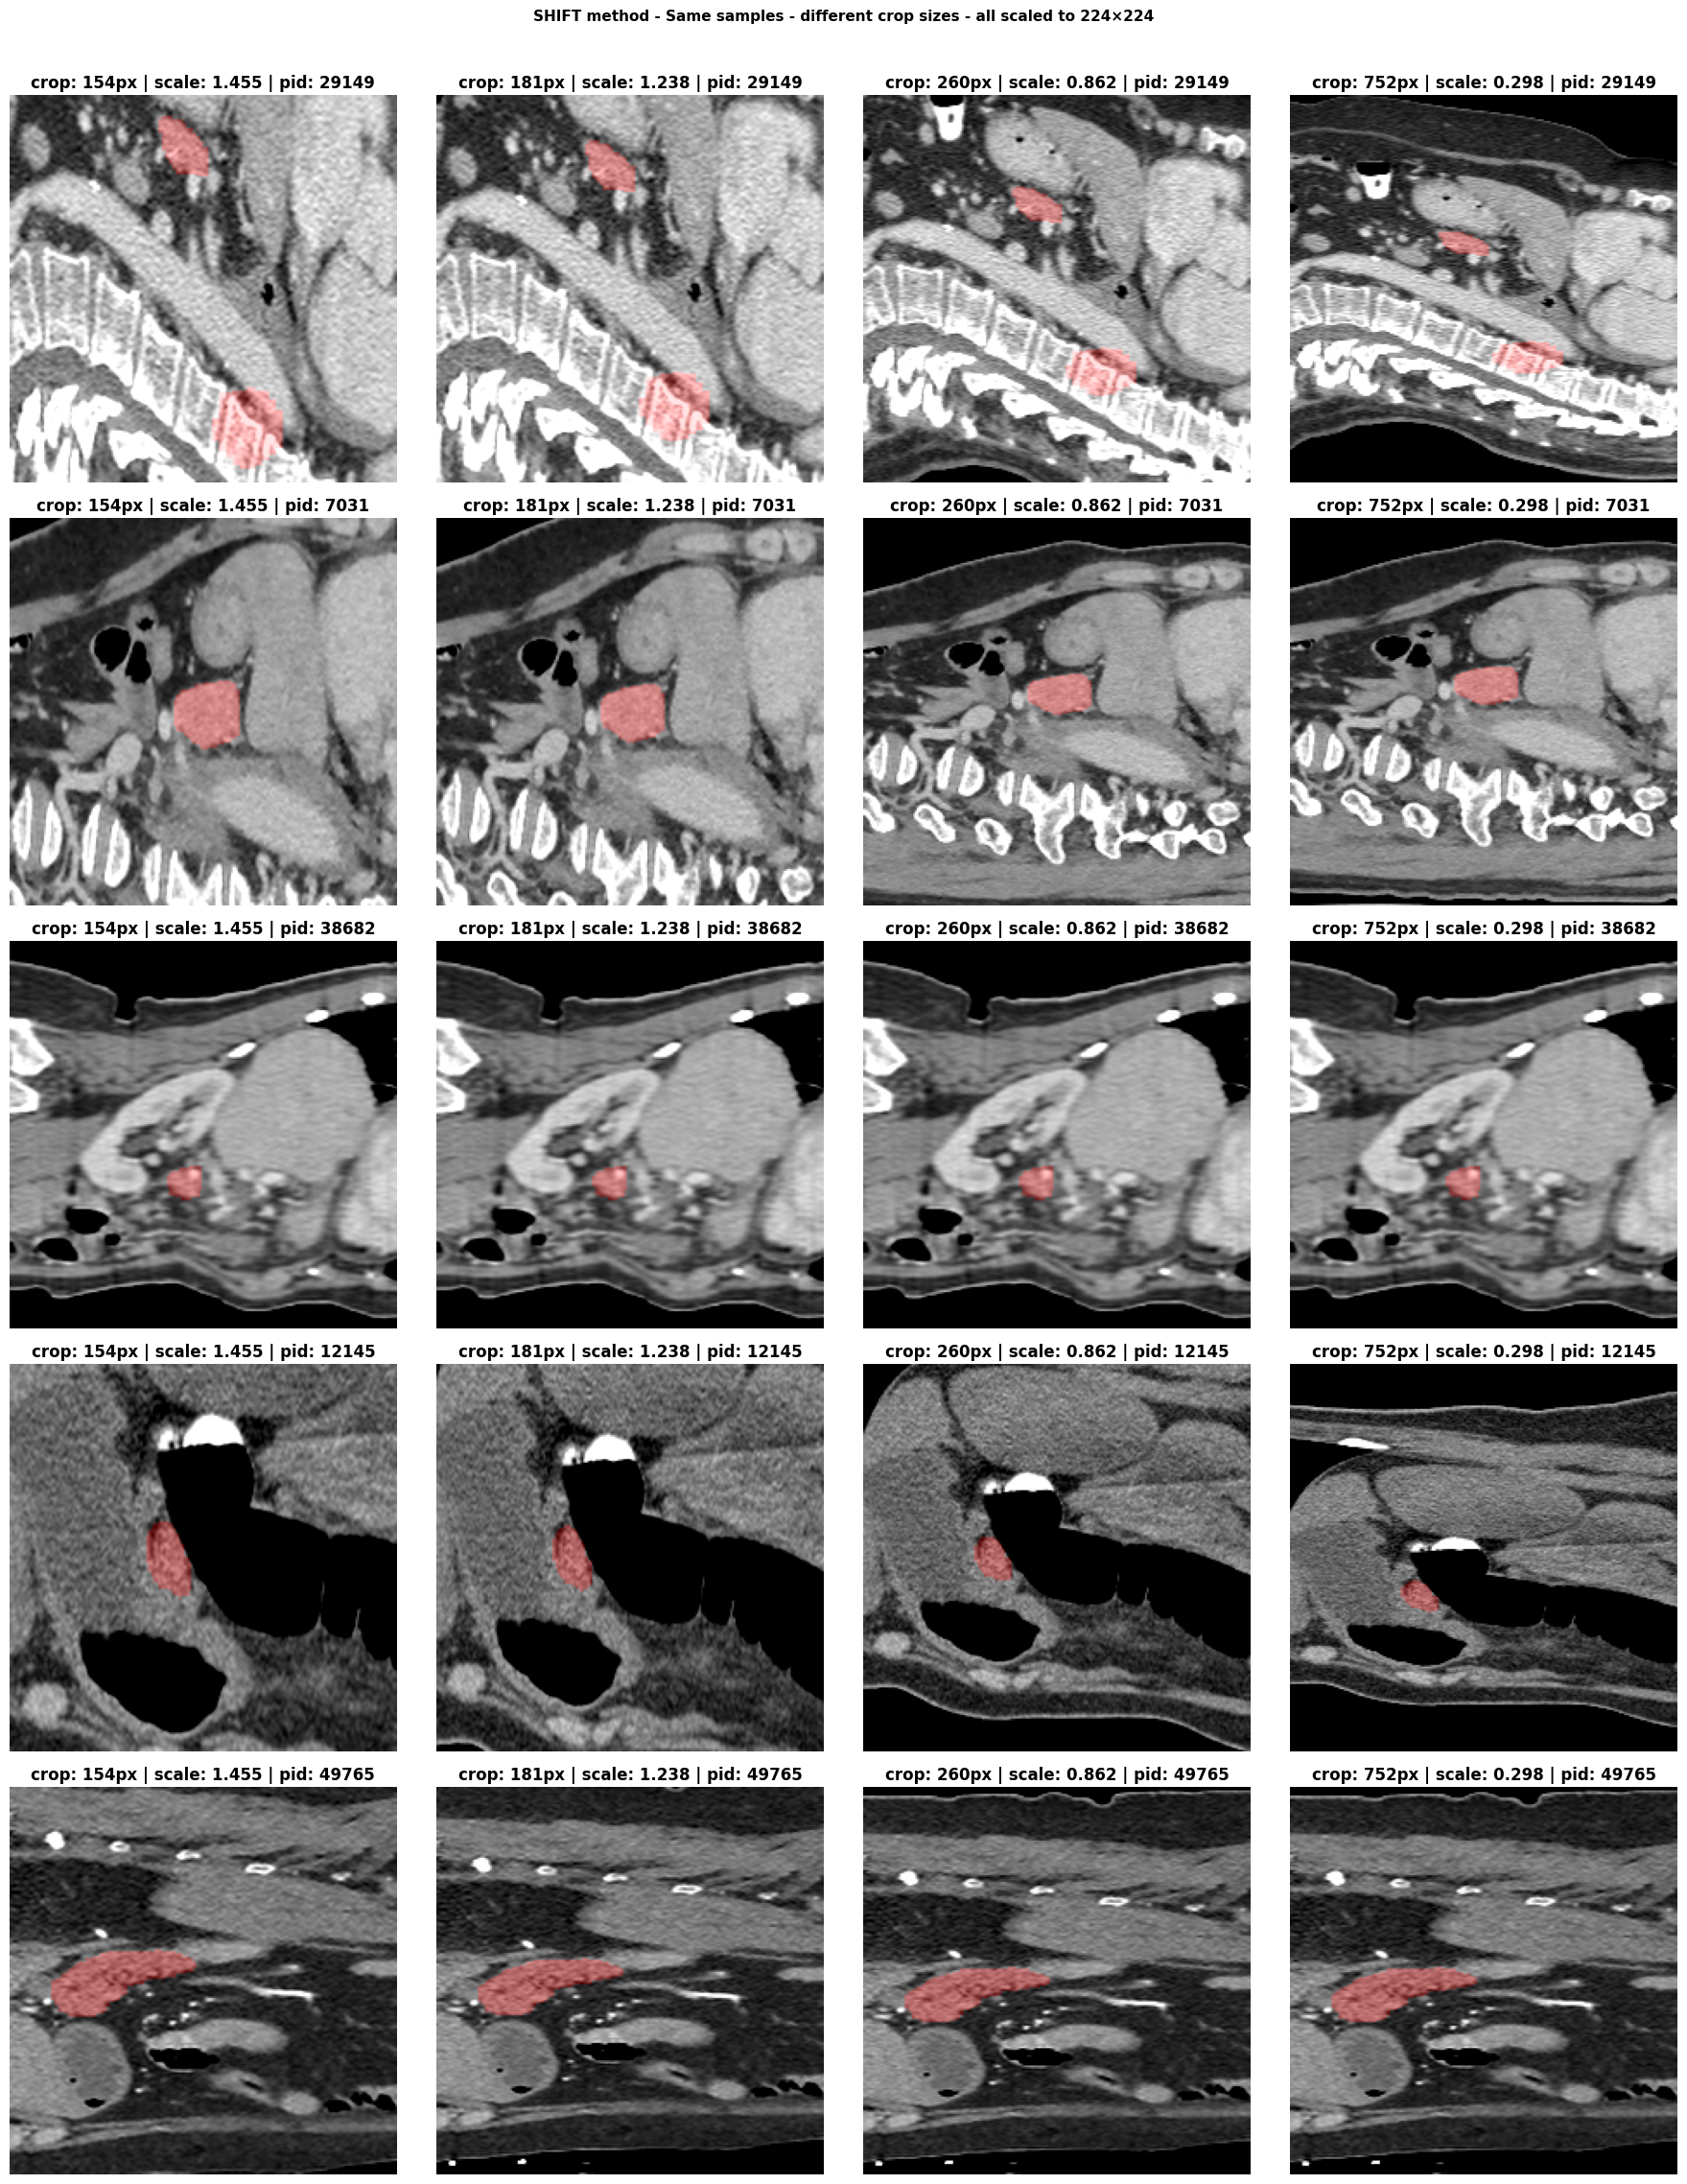

In [16]:
percentiles = analyze_percentiles(REPORT)

chosen_crop = percentiles["p95"] + MARGIN

compare_crop_sizes(CSV, crop_sizes=[
    percentiles["p90"] + MARGIN,
    percentiles["p95"] + MARGIN,
    percentiles["p99"] + MARGIN,
    percentiles["max"] + MARGIN
], n_samples=10)

## Without resampling

In [ ]:
def shifted_crop_2d(ct_slice, mask_slice, crop_size, spacing=(1.0, 1.0)):
    """
    Standardizes the slice to 1.0mm spacing, then applies a shifted center crop.
    spacing: tuple of (spacing_y, spacing_x) from nibabel header zooms.
    """
    # 1. PHYSICAL RESAMPLING (Standardize to 1.0mm)
    # This aligns the image pixels with real-world millimeters
    resample_h = int(round(ct_slice.shape[0] * spacing[0]))
    resample_w = int(round(ct_slice.shape[1] * spacing[1]))
    
    ct_resampled = cv2.resize(ct_slice, (resample_w, resample_h), interpolation=cv2.INTER_LANCZOS4)
    mask_resampled = cv2.resize(mask_slice, (resample_w, resample_h), interpolation=cv2.INTER_NEAREST)

    # 2. FIND ROI IN RESAMPLED SPACE
    yx = np.where(mask_resampled > 0)

    # Safety check for empty masks
    if len(yx[0]) == 0:
        return None, None, {"error": "empty mask after resampling"}

    # Center coordinates in the new 1.0mm grid
    cy = int((yx[0].min() + yx[0].max()) / 2)
    cx = int((yx[1].min() + yx[1].max()) / 2)
    
    half = crop_size // 2

    # 3. DEFINE WINDOW (Shifted Logic)
    y1, y2 = cy - half, cy + half
    x1, x2 = cx - half, cx + half

    img_h, img_w = ct_resampled.shape
    
    # Shift Y if out of bounds
    if y1 < 0:
        y2 += -y1
        y1 = 0
    elif y2 > img_h:
        y1 -= (y2 - img_h)
        y2 = img_h

    # Shift X if out of bounds
    if x1 < 0:
        x2 += -x1
        x1 = 0
    elif x2 > img_w:
        x1 -= (x2 - img_w)
        x2 = img_w

    # Final boundary clamping
    y1, x1 = max(0, y1), max(0, x1)
    y2, x2 = min(img_h, y1 + crop_size), min(img_w, x1 + crop_size)

    # 4. EXTRACT CROP
    ct_crop   = ct_resampled[y1:y2, x1:x2]
    mask_crop = mask_resampled[y1:y2, x1:x2]

    # Meta for tracking physical size
    meta = {
        "original_spacing": spacing,
        "resampled_shape": (resample_h, resample_w),
        "roi_physical_h": int(yx[0].max() - yx[0].min()),
        "roi_physical_w": int(yx[1].max() - yx[1].min()),
        "shifted": (y1 == 0 or y2 == img_h or x1 == 0 or x2 == img_w)
    }

    return ct_crop, mask_crop, meta